In [9]:
from dotenv import load_dotenv
import os
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('../env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
MODEL_API_VERSION=os.getenv('MODEL_API_VERSION')
if MODEL_API_VERSION:
    os.environ['MODEL_API_VERSION'] = MODEL_API_VERSION
if AZURE_OPENAI_API_KEY:
    print(AZURE_OPENAI_API_KEY[:10])
else:
    print("AZURE_OPENAI_API_KEY가 설정되지 않았습니다.")
print(MODEL_NAME, MODEL_API_VERSION)

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

langsmith_key = os.getenv('LANGSMITH_API_KEY')
if langsmith_key:
    os.environ['LANGCHAIN_API_KEY'] = langsmith_key
ep = os.getenv('LANGCHAIN_ENDPOINT')
if ep:
    os.environ['LANGCHAIN_ENDPOINT'] = ep
os.environ['LANGCHAIN_TRACING_V2'] = 'false' #true, false
os.environ['LANGCHAIN_PROJECT'] = 'AGENT'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    _lk = os.getenv('LANGSMITH_API_KEY')
    if _lk and len(_lk) > 0:
        print('랭스미스로 추적 중입니다 :', _lk[:10])
    else:
        print('랭스미스 키가 확인되지 않았습니다.')

3BHTZdVIXx
gpt-5-nano 2025-01-01-preview


## 오케스트레이션(Refiner) - 여행 플랜 작성기

날씨, 호텔 등의 정보를 받아 여행 플랜을 작성하는 멀티 에이전트 앱 만들어보기

## API - 1) Open-Meteo

Open meteo는 무료로 사용할 수 있는 날씨 API로 키 없이 간단하게 다양한 정보를 받을 수 있음

위도(Lat), 경도(Lon)를 입력해야 하는데 geocoding api를 사용하면 도시의 좌표를 찾을 수 있음

### - geocoding으로 좌표 받기

In [10]:
import requests

geo_url = "https://geocoding-api.open-meteo.com/v1/search"
params = {"name": "Seoul", "count": 1, "language": "en"}
geo_res = requests.get(geo_url, params=params).json()

lat, lon = geo_res["results"][0]["latitude"], geo_res["results"][0]["longitude"]
tz = geo_res["results"][0]["timezone"]
print(lat, lon, tz)

37.566 126.9784 Asia/Seoul


### - Open Meteo로 다양한 날씨 정보 받기

In [11]:
weather_url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": lat,
    "longitude": lon,
    "hourly": "temperature_2m,precipitation,windspeed_10m", # 2m 높이의 기온, 강수량
    "timezone": tz, # 해당 지역의 시간대
}
res = requests.get(weather_url, params=params).json()
import json
print(json.dumps(res, indent=4))

{
    "latitude": 37.55,
    "longitude": 127.0,
    "generationtime_ms": 0.34737586975097656,
    "utc_offset_seconds": 32400,
    "timezone": "Asia/Seoul",
    "timezone_abbreviation": "GMT+9",
    "elevation": 27.0,
    "hourly_units": {
        "time": "iso8601",
        "temperature_2m": "\u00b0C",
        "precipitation": "mm",
        "windspeed_10m": "km/h"
    },
    "hourly": {
        "time": [
            "2026-02-25T00:00",
            "2026-02-25T01:00",
            "2026-02-25T02:00",
            "2026-02-25T03:00",
            "2026-02-25T04:00",
            "2026-02-25T05:00",
            "2026-02-25T06:00",
            "2026-02-25T07:00",
            "2026-02-25T08:00",
            "2026-02-25T09:00",
            "2026-02-25T10:00",
            "2026-02-25T11:00",
            "2026-02-25T12:00",
            "2026-02-25T13:00",
            "2026-02-25T14:00",
            "2026-02-25T15:00",
            "2026-02-25T16:00",
            "2026-02-25T17:00",
            "20

시간대별 정보 hourly=...

- temperature_2m : 2m 높이 기온 (°C)
- relativehumidity_2m : 2m 상대 습도 (%)
- dewpoint_2m : 이슬점 (°C)
- apparent_temperature : 체감 온도 (°C)
- precipitation : 강수량 (mm) (비, 눈, 우박 포함)
- rain : 비 (mm)
- snowfall : 적설량 (cm)
- cloudcover : 운량 (%)
- windspeed_10m : 풍속 (10m 높이, km/h or m/s)
- winddirection_10m : 풍향 (°)
- pressure_msl : 해면기압 (hPa)
- visibility : 가시거리 (m)
- shortwave_radiation : 일사량 (W/m²)

일별 정보 daily=... 사용.

- temperature_2m_max / temperature_2m_min : 최고/최저 기온 (°C)
- apparent_temperature_max / apparent_temperature_min : 체감 최고/최저 기온
- sunrise / sunset : 일출/일몰 시간
- daylight_duration : 낮 길이 (초)
- precipitation_sum : 하루 총 강수량 (mm)
- rain_sum / snowfall_sum : 비/눈 총량
- windspeed_10m_max : 하루 최대 풍속
- windgusts_10m_max : 최대 돌풍
- uv_index_max : 최고 자외선 지수
- weathercode : 날씨 코드 (맑음/구름/비/눈 등)

In [12]:
times = res["hourly"]["time"]
temps = res["hourly"]["temperature_2m"]
rain = res["hourly"]["precipitation"]
wind = res["hourly"]["windspeed_10m"]

print(f'데이터 길이: {len(times)}시간')

for idx, (t, temp, r, w) in enumerate(zip(times, temps, rain, wind)):
    if idx >= 5:
        break
    print(f"{t} → {temp}°C, 강수량 {r}mm, 풍속 {w}m/s")

데이터 길이: 168시간
2026-02-25T00:00 → -1.6°C, 강수량 0.0mm, 풍속 4.6m/s
2026-02-25T01:00 → -2.2°C, 강수량 0.0mm, 풍속 4.0m/s
2026-02-25T02:00 → -2.6°C, 강수량 0.0mm, 풍속 3.8m/s
2026-02-25T03:00 → -2.8°C, 강수량 0.0mm, 풍속 3.9m/s
2026-02-25T04:00 → -2.9°C, 강수량 0.0mm, 풍속 3.5m/s


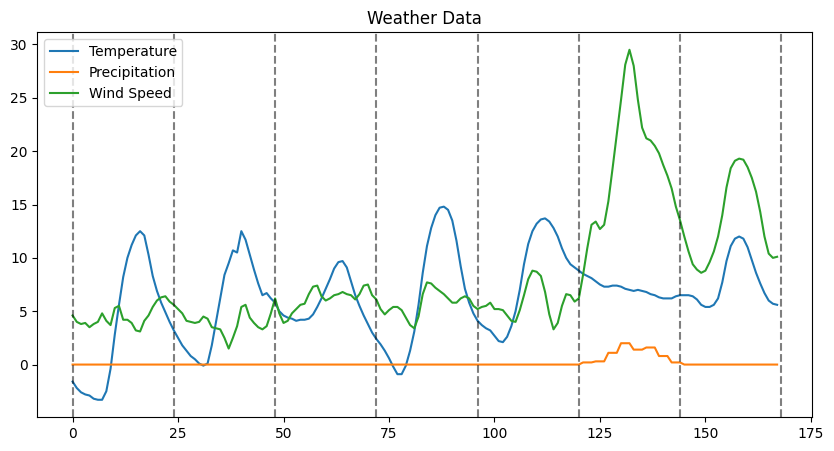

In [13]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(temps, label="Temperature")
plt.plot(rain, label="Precipitation")
plt.plot(wind, label="Wind Speed")
for i in range(len(times)//24 + 1):
    plt.axvline(x=i*24, color='black', linestyle='--', alpha=0.5)
plt.legend(loc = "upper left")
plt.title("Weather Data")
plt.show()

## API - 2) Overpass

OpenStreetMap(OSM) 데이터를 쿼리(Query)할 수 있게 해주는 API로 도로나 건물, 버스 정류장, 카페, 병원 등 다양한 객체 정보를 가져올 수 있음

위치는 https://www.openstreetmap.org/에서 찾을 수 있음

- restaurant, fast_food, cafe
- bank, atm, pharmacy, hospital
- bus_station, bus_stop, taxi, parking, fuel
- park, police, toilets

In [14]:
import requests
from requests.adapters import HTTPAdapter

OVERPASS_URL = "https://overpass-api.de/api/interpreter"

# KT 좌표 : 37.359010, 127.114856
# KT 근처 카페 검색 0.01는 약 1km
query = """
[out:json][timeout:25];
node["amenity"="cafe"](37.355,127.11,37.365,127.12);
out;
"""

response = requests.get(OVERPASS_URL, params={"data": query})
data = response.json()

for element in data["elements"][:5]:
    print(f"카페 이름: {element['tags'].get('name', '')}")
    print(f"위치: {element['lat']}, {element['lon']}")
    print("---")

카페 이름: 스타벅스 정자동
위치: 37.3632023, 127.1141419
---


In [15]:
query = """
[out:json][timeout:25];
node["amenity"="restaurant"](around:500,37.359,127.114);
out;
"""

response = requests.get(OVERPASS_URL, params={"data": query})
data = response.json()

for element in data["elements"][:5]:
    print(f"식당 이름: {element['tags'].get('name', '')}")
    print(f"위치: {element['lat']}, {element['lon']}")
    print("---")

식당 이름: 춘향골남원추어탕
위치: 37.3600374, 127.113064
---
식당 이름: 김명자낙지마당 정자점
위치: 37.3605929, 127.1145191
---
식당 이름: 고향집 삼계탕
위치: 37.3610031, 127.1131732
---
식당 이름: 푸른바다 볼테기
위치: 37.3612194, 127.1131608
---
식당 이름: 춘향골남원추어탕
위치: 37.3602189, 127.1131659
---


In [16]:
# OpenStreetMap에서 호텔은 tourism=hotel (node·way·relation 모두 검색)
query = """
[out:json][timeout:25];
(
  node["tourism"="hotel"](around:3000,37.359,127.114);
);
out center 20;
"""

response = requests.get(OVERPASS_URL, params={"data": query})
data = response.json()

for element in data["elements"][:5]:
    name = element.get("tags", {}).get("name", "(이름 없음)")
    lat = element.get("lat") or (element.get("center", {}) or {}).get("lat")
    lon = element.get("lon") or (element.get("center", {}) or {}).get("lon")
    print(f"호텔 이름: {name}")
    print(f"위치: {lat}, {lon}")
    print("---")

호텔 이름: 호텔갤러리
위치: 37.3852675, 127.1210473
---
호텔 이름: SR호텔
위치: 37.3854879, 127.1201143
---
호텔 이름: DoubleTree by Hilton Seoul Pangyo
위치: 37.3808185, 127.1039857
---
호텔 이름: DoubleTree by Hilton Seoul Pangyo Residences
위치: 37.3803799, 127.1046931
---
호텔 이름: Hotel JJ
위치: 37.3795831, 127.1155184
---


In [17]:
llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,
    azure_deployment=MODEL_NAME,
    api_version=os.environ.get('MODEL_API_VERSION', '2024-12-01-preview'),
    model = MODEL_NAME,
)

In [18]:
import textwrap, requests, os
from typing import TypedDict, List, Dict, Any, Literal, NotRequired
from langchain_tavily import TavilySearch
from datetime import date, timedelta
from dateutil import parser as dateparser

from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


USE_OVERPASS = True
OPEN_METEO_GEOCODE = "https://geocoding-api.open-meteo.com/v1/search"
OPEN_METEO_FORECAST = "https://api.open-meteo.com/v1/forecast"
WIKI_SUMMARY      = "https://en.wikipedia.org/api/rest_v1/page/summary/{}"
WIKI_SEARCH       = "https://en.wikipedia.org/w/api.php"
WIKI_REST_SEARCH  = "https://en.wikipedia.org/w/rest.php/v1/search/title"
HEADERS = {"User-Agent": "AgenticTravel/1.0 (contact: you@example.com)"}
OVERPASS_API = "https://overpass-api.de/api/interpreter"
# Tavily: 관광지 등 능동 검색용 (TAVILY_API_KEY 필요)
_tavily_api = os.getenv("TAVILY_API_KEY")
TAVILY_SEARCH = TavilySearch(max_results=10, api_key=_tavily_api) if _tavily_api else None

# 여행을 위한 여행자의 허용도를 파라미터로 설정
RAIN_MM_OK = 0.2 # 이정도 비는 괜찮아
WIND_MPS_MAX = 9.0 # 이정도 바람까지 괜찮아
TEMP_MIN_C = 10.0 # 최저 기온
TEMP_MAX_C = 30.0 #최고 기온

MAX_REVISIONS = 3

# ---------------- State ----------------
class TripState(TypedDict):
    # 유저의 입력값 (여행 정보)
    destination: str
    start_date: str  # YYYY-MM-DD
    nights: int
    preferences: str

    # 데이터 조회 결과
    tz: str
    lat: float
    lon: float
    weather: Dict[str, Any]
    wiki_summary: str
    pois: List[Dict[str, Any]]
    hotels: List[Dict[str, Any]]

    # 추가 정보
    refined_intent: Dict[str, Any]
    poi_classes: Dict[str, Any]
    allocation: Dict[str, Any]
    plan_markdown: str
    critique: str
    revisions: int
    ok: bool

def _fmt_day(d: date) -> str:
    return d.strftime("%Y-%m-%d")

def _date_range(start: date, nights: int) -> List[date]:
    return [start + timedelta(days=i) for i in range(nights + 1)]

def _iso_to_date(s: str) -> date:
    return dateparser.parse(s).date()

### 정보 수집 에이전트 들
- get_geocode : 위도, 경도, 타임존
- weather_agent : 날씨 정보 수집
- poi_agent : 관광지 정보 수집
- overpass_hotels_agent : 호텔 정보 수집
- gather : 수집 wait point

In [19]:
def get_geocode(state: TripState) -> Dict:
    """위도, 경도, 타임존 조회"""
    dest = state["destination"]

    prompt = ChatPromptTemplate.from_template(
        """
        여행자의 목적지 문장을 받아서 지역의 이름을 영어로 추출하세요.

        예시:
        - 미국 뉴욕 --> New York
        - 일본 도쿄 --> Tokyo
        - 프랑스 파리 --> Paris
        - 이탈리아 로마 --> Rome
        - 스페인 바르셀로나 --> Barcelona

        입력 장소 : {dest}
        """
    )
    chain = prompt | llm | StrOutputParser()
    dest = chain.invoke({"dest": dest})
    r = requests.get(OPEN_METEO_GEOCODE, params={"name": dest, "count": 1, "language": "en"}, timeout=20)
    r.raise_for_status()
    results = r.json().get("results") or []

    if not results:
        raise RuntimeError("Destination not found")

    top = results[0]
    lat, lon = float(top["latitude"]), float(top["longitude"])
    tz = top.get("timezone") or "UTC"

    return {"lat": lat, "lon": lon, "tz": tz, "destination": dest}

def weather_agent(state: TripState) -> Dict:
    # 위도, 경도, 타임존 조회
    lat, lon = float(state["lat"]), float(state["lon"])
    tz = state["tz"]

    # 날씨 정보 조회
    start = _iso_to_date(state["start_date"])
    end = start + timedelta(days=max(1, state["nights"]))

    # 여행 기간의 날씨 정보 조회
    f = requests.get(OPEN_METEO_FORECAST, params={
        "latitude": lat, "longitude": lon,
        "hourly": ["temperature_2m","precipitation","windspeed_10m"], # 기온, 강수량, 풍속
        "daily": ["temperature_2m_max","temperature_2m_min","precipitation_sum","precipitation_hours","wind_speed_10m_max"], # 최고/최저 기온, 총 강수량, 강수 발생 시간, 최대 풍속
        "timezone": tz,
        "start_date": _fmt_day(start),
        "end_date": _fmt_day(end),
    }, timeout=30)
    f.raise_for_status()

    return {"weather": f.json()}


def _tavily_to_pois(dest: str, max_total: int = 30) -> List[Dict[str, Any]]:
    """Tavily로 여러 쿼리를 실행해 추천 여행지 POI 목록 수집."""
    if not TAVILY_SEARCH:
        return []
    seen_urls: set = set()
    pois: List[Dict[str, Any]] = []
    queries = [
        f"{dest} best tourist attractions must see",
        f"{dest} top things to do recommended",
        f"{dest} places to visit travel guide",
        f"{dest} must see sights and activities",
    ]
    for q in queries:
        if len(pois) >= max_total:
            break
        try:
            out = TAVILY_SEARCH.invoke(q)
            # Document 리스트 또는 유사 구조 처리
            items = out if isinstance(out, list) else (getattr(out, "results", []) or [])
            for doc in items:
                if len(pois) >= max_total:
                    break
                url = (getattr(doc, "metadata", {}) or {}).get("url", "") or (doc.get("url", "") if isinstance(doc, dict) else "")
                if url and url in seen_urls:
                    continue
                seen_urls.add(url)
                _meta = getattr(doc, "metadata", None) or (doc if isinstance(doc, dict) else {})
                title = ((_meta.get("title") or (doc.get("title", "") if isinstance(doc, dict) else "") or ""))[:120]
                snippet = (getattr(doc, "page_content", None) or (doc.get("content", "") if isinstance(doc, dict) else "") or "")[:600]
                pois.append({"title": title or "(No title)", "snippet": snippet, "url": url or ""})
        except Exception:
            continue
    return pois

def poi_agent(state: TripState) -> Dict:
    dest = state["destination"].strip()
    # Wikipedia 요약
    summary = ""
    try:
        s = requests.get(WIKI_SUMMARY.format(requests.utils.quote(dest)), headers=HEADERS, timeout=20)
        if s.ok:
            summary = s.json().get("extract") or ""
    except Exception:
        pass

    pois: List[Dict[str, Any]] = []
    # Wikipedia 검색 POI
    params = {"action":"query","list":"search","srsearch":f"{dest} tourist attractions OR museums OR parks OR markets","srlimit":12,"format":"json"}
    try:
        q = requests.get(WIKI_SEARCH, params=params, headers=HEADERS, timeout=20)
        if q.ok:
            hits = q.json().get("query", {}).get("search", [])
            for h in hits[:10]:
                title = h.get("title")
                pois.append({"title": title, "snippet": h.get("snippet", ""), "url": f"https://en.wikipedia.org/wiki/{requests.utils.quote(title or '')}"})
        else:
            r = requests.get(WIKI_REST_SEARCH, params={"q": dest, "limit": 12}, headers=HEADERS, timeout=20)
            if r.ok:
                for item in (r.json().get("pages") or [])[:10]:
                    title = item.get("title")
                    pois.append({"title": title, "snippet": item.get("description",""), "url": f"https://en.wikipedia.org/wiki/{requests.utils.quote(title or '')}"})
    except Exception:
        pass

    # Tavily로 다양한 추천 여행지 추가 (충분한 양, 중복 제거)
    tavily_pois = _tavily_to_pois(dest, max_total=25)
    seen = {p.get("url") or p.get("title") for p in pois}
    for p in tavily_pois:
        if (p.get("url") or p.get("title")) not in seen:
            seen.add(p.get("url") or p.get("title"))
            pois.append(p)

    return {"wiki_summary": summary or "", "pois": pois}


def overpass_hotels_agent(state: TripState) -> Dict:
    """호텔 정보 수집"""
    if not USE_OVERPASS:
        return {"hotels": []}
    lat, lon = state["lat"], state["lon"]
    query = textwrap.dedent(f"""
    [out:json];
    (
      node["tourism"="hotel"](around:4000,{lat},{lon});
    );
    out center 20;
    """)
    r = requests.post(OVERPASS_API, data={"data": query}, timeout=45)
    hotels: List[Dict[str, Any]] = []
    if r.ok:
        for el in r.json().get("elements", [])[:20]:
            tags = el.get("tags", {})
            name = tags.get("name") or "(Unnamed hotel)"
            star = tags.get("stars"); addr = ", ".join([tags.get(k, "") for k in ["addr:street","addr:housenumber","addr:city"] if tags.get(k)])
            hotels.append({"name": name, "stars": star, "address": addr})
    return {"hotels": hotels}

def gather(_state: TripState) -> dict:
    """
    모든 정보를 수집을 확인하는 중간 단계
    """
    return {}

### 정보를 처리하고 여행 계획을 세우는 에이전트
- **intent_refiner**: 목적지·선호를 바탕으로 의도를 구조화 (audience, pace, interests, 제약). 이후 배정·일정에 반영.
- **poi_classifier**: 수집된 POI(pois)를 실내/실외·테마·우선순위로 분류해 JSON으로 출력. day_block_allocator가 사용.
- **day_block_allocator**: 날씨·POI 분류·의도를 보고 일별 실내/실외 블록을 배정 (강수·풍속·온도 임계치 적용).
- **itinerary_composer**: 배정 JSON + 호텔 + 도시 요약을 읽기 쉬운 마크다운 일정으로 변환.

In [20]:
from typing import List, Literal, Optional, Dict, TypedDict
from pydantic import BaseModel, Field

class RefinedIntent(BaseModel):
    audience: Literal["solo", "couple", "family"] = Field(..., description="여행자 구성")
    pace: Literal["relaxed", "packed"] = Field(..., description="일정 템포")
    interests: List[str] = Field(..., description="관심사(우선순위 상위부터)")
    food_prefs: Optional[str] = Field(None, description="음식 취향/제약")
    budget_level: Literal["low", "med", "high"] = Field(..., description="예산 레벨")
    hard_constraints: List[str] = Field(default_factory=list, description="알레르기/필수 방문/야간 이동 금지 등 제약")


class POIClass(BaseModel):
    title: str = Field(..., description="장소 이름")
    type: Literal["indoor", "outdoor", "mixed"] = Field(..., description="실내/실외 분류")
    theme: Literal["museum", "temple", "park", "market", "neighborhood", "view", "food", "other"] = Field(..., description="장소 테마")
    priority: int = Field(..., description="우선순위(1~5)")


class POIClassifyResult(BaseModel):
    pois: List[POIClass] = Field(default_factory=list, description="중복 제거된 POI 목록")


class DayAllocation(BaseModel):
    date: str = Field(..., description="YYYY-MM-DD")
    indoor: List[str] = Field(default_factory=list, description="실내 장소 추천")
    outdoor: List[str] = Field(default_factory=list, description="실외 장소 추천")
    notes: str = Field(default="", description="배정 이유 또는 주의사항")


class DayAllocationResult(BaseModel):
    days: List[DayAllocation] = Field(default_factory=list, description="일자별 배정 결과")


intent_llm = llm.with_structured_output(RefinedIntent, method="function_calling")
poi_llm = llm.with_structured_output(POIClassifyResult, method="function_calling")
allocation_llm = llm.with_structured_output(DayAllocationResult, method="function_calling")

def intent_refiner(state: TripState) -> Dict:
    """사용자의 지시와 선호가 불명확할 때 목적지를 명시적으로 제약하고 페르소나를 생성"""

    REFINE_PROMPT = ChatPromptTemplate.from_template("""
너는 여행 일정을 조정하기 위해 사용자의 목적을 분석하고 정리하는 역할을 한다.
사용자의 의도를 아래 JSON 스키마에 맞춰 변환하라.

필수 필드:
- audience: 혼자(solo)/연인(couple)/가족(family) 중 선택
- pace: 편안한(relaxed)/패키지(packed) 중 선택
- interests: 중요도 순으로 나열
- budget_level: low/med/high 중 선택
선택 필드:
- food_prefs: 음식 취향/제약
- hard_constraints: 알레르기, 반드시 가야 할 곳, 야간 이동 금지 등

사용자 정보:
- 목적지: {dest}
- 선호 텍스트: {prefs}

누락된 항목은 {dest} 맥락에서 합리적으로 채워라.
반드시 스키마에 맞게 작성하라.
""")

    dest = state["destination"]
    prefs = state.get("preferences") or ""
    result: RefinedIntent = (REFINE_PROMPT | intent_llm).invoke({"dest": dest, "prefs": prefs})
    return {"refined_intent": result.model_dump()}


def poi_classifier(state: TripState) -> Dict:
    """위키 제목/스니펫을 바탕으로 관광 명소(indoor/outdoor/theme)를 분류 및 중복 제거"""

    pois = state.get("pois", [])
    sample = "\n".join([f"- {p.get('title')}: {p.get('snippet','')}" for p in pois[:12]])
    P = ChatPromptTemplate.from_template(
        """
        아래 장소들을 분류하세요.
        필드: title, type(indoor|outdoor|mixed), theme(museum|temple|park|market|neighborhood|view|food|other), priority(1-5).
        중복 항목은 병합하고 결과를 pois 리스트로 반환하세요.

        입력:
        {sample}
        """
    )
    result: POIClassifyResult = (P | poi_llm).invoke({"sample": sample})
    return {"poi_classes": result.model_dump()}


def day_block_allocator(state: TripState) -> Dict:
    """날씨 + 사용자의 제약을 고려하여 일별 야외/실내 여행을 할당"""

    w = state["weather"]
    start = _iso_to_date(state["start_date"])
    days = _date_range(start, state["nights"])[:-1]

    daily = w.get("daily", {})
    day_rows = []
    for i, d in enumerate(days):
        row = {
            "date": _fmt_day(d),
            "tmax": daily.get("temperature_2m_max", [None]*10)[i],
            "tmin": daily.get("temperature_2m_min", [None]*10)[i],
            "precip": daily.get("precipitation_sum", [None]*10)[i],
            "windmax": daily.get("wind_speed_10m_max", [None]*10)[i],
        }
        day_rows.append(row)

    P = ChatPromptTemplate.from_template(
        """
        일 단위 날씨와 POI 분류를 바탕으로, 가능하면 하루에 실외와 실내 장소를 적절한 수로 배정하세요.
        강수량이 {RAIN}mm 초과, 풍속 {WIND}m/s 초과, 혹은 온도가 [{TMIN},{TMAX}]℃ 범위를 벗어나면 실외를 피합니다.
        결과는 days 리스트(각 원소: date, indoor, outdoor, notes)로 반환하세요.

        날씨:
        {weather}
        POI:
        {pois}
        제약:
        {intent}
        """
    )

    result: DayAllocationResult = (P | allocation_llm).invoke({
        "RAIN": RAIN_MM_OK,
        "WIND": WIND_MPS_MAX,
        "TMIN": TEMP_MIN_C,
        "TMAX": TEMP_MAX_C,
        "weather": day_rows,
        "pois": state.get("poi_classes", {"pois": []}),
        "intent": state.get("refined_intent", {}),
    })
    return {"allocation": result.model_dump()}


def itinerary_composer(state: TripState) -> Dict:
    """할당 + 호텔 + 요약을 친절한 마크다운 일정으로 변환"""

    P = ChatPromptTemplate.from_template(
        """
        {dest} {nights}박 {nights}+1 일 일정에 대해, 아래 배정 JSON을 사용해 간결하고 친근한 마크다운 일정을 작성하라:
        {alloc}
        형식: 날짜 헤더, 각 블록에 테마에 맞는 장소 아이디어(구체적 지명 가상 제시 가능),
        하루 한 줄의 간단 교통 팁, 그리고 "이 일정이 좋은 이유" 소제목을 덧붙여라.
        요청자는 한국인이므로 외국어를 모르는 한국인을 배려해서 결과를 작성하라.
        호텔 목록이 있다면 짧게 추가하라:
        {hotels}
        도시 스냅샷(불릿 5개)도 포함하라:
        {summary}
        """
    )
    hotels_md = "\n".join([f"- {h['name']}" + (f" ({h['stars']}★)" if h.get('stars') else "") for h in state.get("hotels", [])[:8]])
    out = (P | llm | StrOutputParser()).invoke({
        "dest": state["destination"], "nights": state["nights"],
        "alloc": state.get("allocation", {}),
        "hotels": hotels_md or "(no hotel data)",
        "summary": state.get("wiki_summary","(no summary)")
    })
    return {"plan_markdown": out}



### 여행 일정의 퀄리티를 올리는 에이전트
- plan_critic : 날씨를 확인하여 여행 일정을 평가
- conductor : 피드백을 토대로 최종안 작성

In [21]:

class CriticResult(BaseModel):
    ok: bool = Field(..., description="현재 계획이 그대로 실행 가능하면 true")
    patch: str = Field(default="", description="수정이 필요할 때 최소 수정 지시")


critic_llm = llm.with_structured_output(CriticResult, method="function_calling")


def plan_critic(state: TripState) -> Dict:
    """날씨/제약에 대한 실현 가능성 평가"""
    P = ChatPromptTemplate.from_template(
        """
        아래 일정을 날씨 임계치(강수>{RAIN}mm, 풍속>{WIND}m/s, 온도 [{TMIN},{TMAX}]℃ 범위 밖)와 사용자 제약에 비추어 검토하세요.
        문제가 있으면 전체를 재작성하지 말고, 실내로 전환/시간대 이동/실외 축소 등의 '최소 수정' 목록만 제안하세요.

        출력 규칙:
        - 실행 가능하면 ok=true
        - 수정 필요하면 ok=false, patch에 수정 요약 작성

        계획:
        {plan}
        """
    )
    result: CriticResult = (P | critic_llm).invoke({
        "RAIN": RAIN_MM_OK,
        "WIND": WIND_MPS_MAX,
        "TMIN": TEMP_MIN_C,
        "TMAX": TEMP_MAX_C,
        "plan": state.get("plan_markdown", ""),
    })
    return {"ok": result.ok, "critique": result.patch}

def conductor(state: TripState) -> Dict:
    """수정이 필요한 경우에만 호출됨"""
    revs = int(state.get("revisions", 0))
    patch = state.get("critique", "")
    plan = state.get("plan_markdown", "")

    P = ChatPromptTemplate.from_template(
        """
        >> 다음 패치 노트를 반영해 일정을 최소한으로 수정하세요:
        요청자는 한국인이므로 외국어를 모르는 한국인을 배려해서 결과를 작성하세요.
        {patch}

        >> 원본 계획:
        {plan}

        >> 원본에서 수정한 최종 여행 계획만 출력하세요. 다른 설명은 생략합니다.
        """
    )

    out = (P | llm | StrOutputParser()).invoke({"patch": patch, "plan": plan})

    # ok는 plan_critic만 써야 함(한 스텝에 한 값만 허용). 수정 후엔 plan_critic이 다시 실행되며 ok를 설정함.
    return {"plan_markdown": out, "revisions": revs + 1}


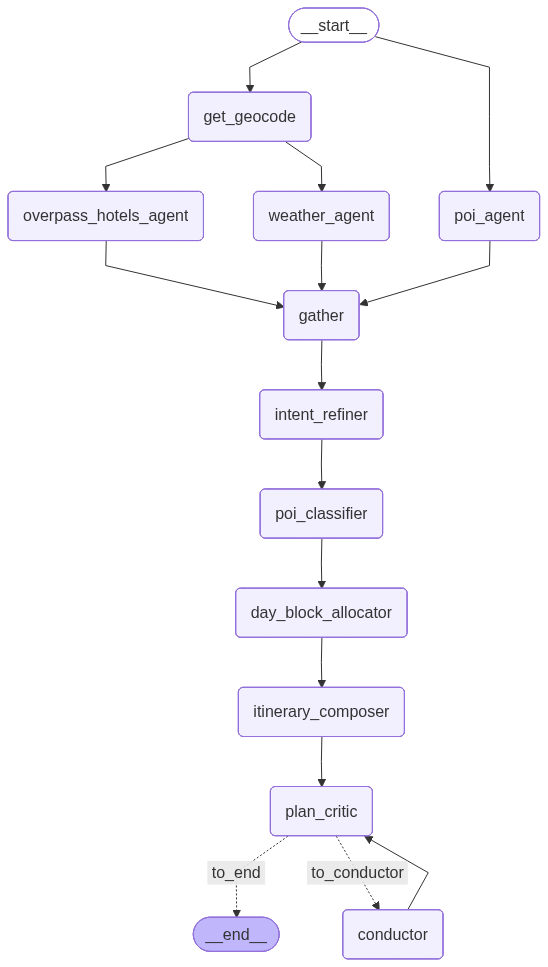

In [22]:
# g = StateGraph(TripState, input_keys=["destination","start_date","nights","preferences"], output_keys=["plan_markdown"])
g = StateGraph(TripState)

g.add_node("get_geocode", get_geocode)
g.add_node("weather_agent", weather_agent)
g.add_node("poi_agent", poi_agent)
g.add_node("overpass_hotels_agent", overpass_hotels_agent)
g.add_node("gather", gather)

g.add_node("intent_refiner", intent_refiner)
g.add_node("poi_classifier", poi_classifier)
g.add_node("day_block_allocator", day_block_allocator)
g.add_node("itinerary_composer", itinerary_composer)
g.add_node("plan_critic", plan_critic)
g.add_node("conductor", conductor)

g.add_edge(START, "get_geocode")
g.add_edge(START, "poi_agent")
g.add_edge("get_geocode", "weather_agent")
g.add_edge("get_geocode", "overpass_hotels_agent")
g.add_edge("poi_agent", "gather")
g.add_edge("weather_agent", "gather")
g.add_edge("overpass_hotels_agent", "gather")

g.add_edge("gather", "intent_refiner")
g.add_edge("intent_refiner", "poi_classifier")
g.add_edge("poi_classifier", "day_block_allocator")
g.add_edge("day_block_allocator", "itinerary_composer")

# 검토
g.add_edge("itinerary_composer", "plan_critic")

def route_after_critic(state: TripState) -> Literal["to_conductor", "to_end"]:
    # ok가 True이면 바로 종료
    if state.get("ok") is True:
        return "to_end"

    # 이미 최대 수정을 거쳤다면 종료
    if int(state.get("revisions", 0)) >= MAX_REVISIONS:
        return "to_end"

    # 수정이 필요하면 conductor로 이동
    return "to_conductor"

g.add_conditional_edges(
    "plan_critic",
    route_after_critic,
    {
        "to_conductor": "conductor",
        "to_end": END
    }
)

g.add_edge("conductor", "plan_critic")

graph = g.compile()
graph

In [23]:
g = StateGraph(TripState)

# 여행을 위한 데이터 조회 노드
g.add_node("get_geocode", get_geocode)
g.add_node("weather_agent", weather_agent)
g.add_node("poi_agent", poi_agent)
g.add_node("overpass_hotels_agent", overpass_hotels_agent)
g.add_node("gather", gather)

# 처리 파이프라인: 의도 정리 → POI 분류 → 일별 배정 → 일정 초안
g.add_node("intent_refiner", intent_refiner)
g.add_node("poi_classifier", poi_classifier)
g.add_node("day_block_allocator", day_block_allocator)
g.add_node("itinerary_composer", itinerary_composer)
g.add_node("plan_critic", plan_critic)
g.add_node("conductor", conductor)

g.add_edge(START, "get_geocode")
g.add_edge(START, "poi_agent")
g.add_edge(START, "intent_refiner") # 유저 입력 분석은 바로 시작 가능!

# 2. 데이터 의존성에 따른 흐름
g.add_edge("get_geocode", "weather_agent")
g.add_edge("get_geocode", "overpass_hotels_agent")
g.add_edge("poi_agent", "poi_classifier") # 장소 수집되면 바로 분류 시작

# 3. 모든 정보가 모이는 지점 (Wait)
g.add_edge("intent_refiner", "gather")
g.add_edge("weather_agent", "gather")
g.add_edge("poi_classifier", "gather")
g.add_edge("overpass_hotels_agent", "gather")

# 4. 최종 조합
g.add_edge("gather", "day_block_allocator") # 배치와 작성을 하나로 합치거나 연이어 수행
g.add_edge("day_block_allocator", "itinerary_composer")


# 검토
g.add_edge("itinerary_composer", "plan_critic")

# 2. Critic 결과에 따른 조건부 분기 (핵심!)
def route_after_critic(state: TripState) -> Literal["to_conductor", "to_end"]:
    # ok가 True이면 바로 종료
    if state.get("ok") is True:
        return "to_end"

    # 이미 최대 수정을 거쳤다면 종료
    if int(state.get("revisions", 0)) >= MAX_REVISIONS:
        return "to_end"

    # 수정이 필요하면 conductor로 이동
    return "to_conductor"

g.add_conditional_edges(
    "plan_critic",
    route_after_critic,
    {
        "to_conductor": "conductor",
        "to_end": END
    }
)

# 3. Conductor는 수정을 마친 후 다시 Critic에게 검사를 받으러 감
g.add_edge("conductor", "plan_critic")

graph = g.compile()

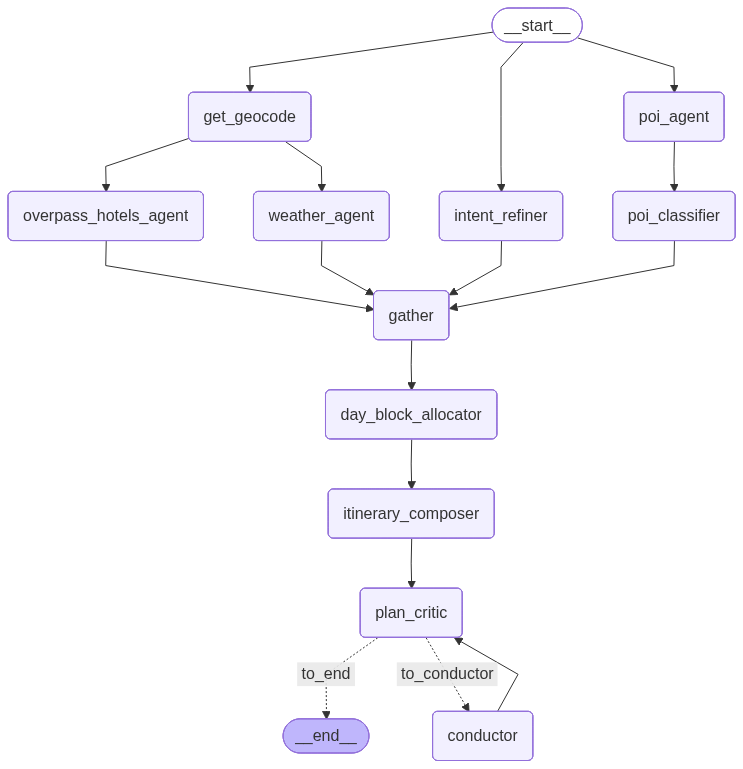

In [24]:
graph

In [25]:
print("=== 오케스트레이션 여행 플래너 ===")
dest = "Tokyo"
start = (date.today() + timedelta(days=7)).strftime("%Y-%m-%d")
nights = 2
prefs = "최대한 맛있는 음식을 많이 먹고 싶어"
out = graph.stream({
    "destination": dest,
    "start_date": start,
    "nights": nights,
    "preferences": prefs,
    "revisions": 0
})
for state in out:
    print(state)

=== 오케스트레이션 여행 플래너 ===
{'get_geocode': {'lat': 35.6895, 'lon': 139.69171, 'tz': 'Asia/Tokyo', 'destination': 'Tokyo'}}
{'poi_agent': {'wiki_summary': 'Tokyo, officially the Tokyo Metropolis, is the capital and most populous city of Japan. With a population of over 14 million in the city proper in 2023, it is one of the most populous urban areas in the world. The Greater Tokyo Area, which includes Tokyo and parts of six neighboring prefectures, is the most populous metropolitan area in the world, with 41 million residents as of 2024.', 'pois': [{'title': 'Lists of tourist attractions', 'snippet': 'are lists of <span class="searchmatch">tourist</span> <span class="searchmatch">attractions</span>. The <span class="searchmatch">tourist</span> <span class="searchmatch">attractions</span> are grouped both by type and by country. List of airshows List of amusement <span class="searchmatch">parks</span> List of aquaria', 'url': 'https://en.wikipedia.org/wiki/Lists%20of%20tourist%20attractions'

In [26]:
# 최종 plan_markdown 보기
final = graph.invoke({"destination": dest, "start_date": start, "nights": nights, "preferences": prefs, "revisions": 0})
print(final["plan_markdown"])

## 2026-03-04

- 테마: 비 소식에도 걱정 없는 실내 맛집과 문화 체험 중심

- 장소 아이디어
  - 팀랩 Planets Tokyo (도쿄 토요스) – 몰입형 디지털 아트로 실내에서도 가득한 감각 체험
  - 무민 미술관 도쿄(가상 전시) – 무민 캐릭터를 테마로 한 가족 친화 실내 전시
  - 일본 음식 문화관(가상) – 일본의 식문화 역사를 한 자리에서 체험하는 실내 체험관

- 하루 교통 팁: 현관에서 바로 지하철로 연결되는 노선 위주로 이동하면 비를 맞지 않고 편하게 다닐 수 있어요.

- 이 일정이 좋은 이유
  - 실내 중심이라 비와 강풍에도 걱정 없이 하루를 꽉 채울 수 있어요.
  - 예술과 식도를 한꺼번에 즐길 수 있어 도쿄의 현대적 매력과 전통적 맛을 한 번에 경험합니다.

---

## 2026-03-05

- 테마: 어제에 이어 실내 위주로, 맛과 문화의 조화를 추구하는 일정

- 장소 아이디어
  - 모리 아트 뮤지엄(Mori Art Museum, 롯폰기 힐스) – 현대 미술의 다양성을 실내에서 감상
  - 팀랩 Planets Tokyo(도요스) – 재방문도 가능한 압도적 디지털 아트 체험
  - 도쿄 디지털 맛집 체험관(가상) – 실내에서 다양한 일본식 간식과 음료를 체험하는 공간

- 하루 교통 팁: 롯폰기와 도요스는 지하철과 무료 셔틀 버스 연결이 좋으니, 한 큐에 여러 장소를 묶어 동선 최적화하기 좋아요.

- 이 일정이 좋은 이유
  - 비바람 속에도 예술과 맛의 조합으로 풍성한 하루를 보낼 수 있습니다.
  - 도쿄의 현대 미술과 디지털 아트를 차근차근 즐길 수 있는 알찬 구성입니다.

---

### 호텔 추천 (짧은 소개)
- Premiere Hotel CABIN 新宿
- THE KNOT TOKYO Shinjuku
- ホテルウィングインターナショナル プレミアム東京四谷
- 新宿ワシントンホテル
- リステル新宿
- Century Southern Tower Hotel
- 新宿プリンスホテル
- 相鉄フレッサイン

---


In [27]:
print("=== 오케스트레이션 여행 플래너 ===")
dest = "대만 가오슝에 여행가고 싶어"
start = (date.today() + timedelta(days=7)).strftime("%Y-%m-%d")
nights = 4
prefs = "관광, 다양한 체험, 바다, 아기와 함께"
final = graph.invoke({
    "destination": dest,
    "start_date": start,
    "nights": nights,
    "preferences": prefs,
    "revisions": 3
})
print(final['plan_markdown'])

=== 오케스트레이션 여행 플래너 ===
### 2026-03-04

- 실내 박물관/과학관: 꿈나무 과학관 실내전시관 (가상) - 아이가 흥미롭게 체험할 수 있는 코너 중심
- 실내 아기 친화형 놀이 공간: 베이비팡 플레이룸 실내 존
- 수유/휴식 공간이 있는 카페: 포근한 모닝 카페(수유실 있음)

교통 팁: 실내 코스를 우선하고 유모차 동선이 잘 연결된 길을 이용해, 야간 이동은 피하도록 낮 시간에 모든 이동을 마무리합니다.

이 일정이 좋은 이유
- 비와 바람에 강한 실내 루트로 하루를 안전하게 보낼 수 있습니다.
- 아기 친화 공간이 집중되어 있어 수유와 휴식이 자연스러운 흐름으로 이어집니다.

---

### 2026-03-05

- 실내 해양관/관람시설: 바다를 주제로 한 실내 전시관(가상) 
- 아기 친화형 체험 전시: 꼬마 해양탐험 체험존
- 실내 카페 및 휴식 공간: 파도빛 카페(수유실 포함)

교통 팁: 강한 바람으로 실외가 어려울 때도, 실내 전시관 간 이동은 쇼핑몰형 실내 동선이나 연결 통로를 활용하면 편합니다.

이 일정이 좋은 이유
- 실내 전시관 위주로 일정이 짜여 있어 비 걱정 없이 두뇌와 손발을 함께 쓸 수 있습니다.
- 충분한 수유/휴식 시간을 두어 피로를 관리하기 좋습니다.

---

### 2026-03-06

- 실내 과학관/체험관: 미래탐험 실내 과학관
- 실내 놀이시설: 더키즈 실내 놀이센터
- 수유/휴식 공간이 있는 카페: 엄마와 아기 카페 '포근한 모닝'

교통 팁: 바람이 여전히 강하므로 실내 코스 위주로 이동하고, 필요 시 엘리베이터 이용 경로를 사전에 확인합니다.

이 일정이 좋은 이유
- 날씨 영향 없이 과학 체험과 놀이를 균형 있게 즐길 수 있습니다.
- 아기 친화적 동선과 휴식 공간이 계속 연결되어 편안합니다.

---

### 2026-03-07

- 실내 해양 상설전시관: 해양의 보물 상설전시관
- 실내 놀이 공간: 키즈룸 실내 놀이 공간
- 실내 카페 및 휴식 공간: 바다빛 휴게 카페

교통 팁: 